# Shelter Occupancy & Capacity — System Pressure Analysis  
Toronto Shelter & Overnight Services (2024–2025)

---

## Objective

This analysis evaluates:

- System-level pressure and utilization trends
- Location-level chronic strain and fragility
- Peak vs average occupancy (resilience)
- Operational implications for capacity planning

The goal is to translate administrative shelter data into actionable insights for public service management.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

In [5]:
import os

print("Before:", os.getcwd())

# Change to project root if currently in notebooks directory
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("After:", os.getcwd())

Before: c:\Users\Owner\OneDrive\Desktop\VScode-projects\sdss-public-service\notebooks
After: c:\Users\Owner\OneDrive\Desktop\VScode-projects\sdss-public-service


In [6]:
import subprocess

def run(cmd: str):
    print(f"\n▶ Running: {cmd}")
    result = subprocess.run(cmd, shell=True, text=True, capture_output=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Command failed: {cmd}")

# Run full pipeline
!python src/etl/ingest_bronze.py
!python src/etl/clean_silver.py
!python src/features/build_mart_location_day.py
!python src/features/build_mart_system_day.py

Bronze table created successfully.
Rows appended: 100337


c:\Users\Owner\OneDrive\Desktop\VScode-projects\sdss-public-service\src\etl\ingest_bronze.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  df["ingestion_time"] = datetime.utcnow()


Silver table created successfully.
Rows: 95018
is_duplicate: 0.0000 (share of rows)
is_missing_capacity: 0.0000 (share of rows)
is_negative_any: 0.0014 (share of rows)
is_over_capacity: 0.0001 (share of rows)
is_rate_mismatch: 0.0000 (share of rows)
Gold mart created successfully.
Rows: 71026
Saved to: data\gold\mart_location_day.csv
System-day mart created successfully.
Rows: 731
Saved to: data\gold\mart_system_day.csv


In [7]:
loc = pd.read_csv("data/gold/mart_location_day.csv", parse_dates=["OCCUPANCY_DATE"])
sysdf = pd.read_csv("data/gold/mart_system_day.csv", parse_dates=["OCCUPANCY_DATE"])

print("Location-day rows:", len(loc))
print("Unique locations:", loc["LOCATION_POSTAL_CODE"].nunique())
print("System-day rows:", len(sysdf))

Location-day rows: 71026
Unique locations: 111
System-day rows: 731


In [8]:
sys_summary = (
    sysdf.groupby("location_type")
         .agg(
             avg_util=("utilization", "mean"),
             p95_util=("utilization", lambda s: s.quantile(0.95)),
             min_util=("utilization", "min"),
             max_util=("utilization", "max"),
             avg_capacity_loss=("capacity_loss_rate", "mean"),
         )
         .sort_values("avg_util", ascending=False)
)

sys_summary

,avg_util,p95_util,min_util,max_util,avg_capacity_loss
location_type,,,,,
fixed_location,0.987397,0.996091,0.957662,0.997384,0.041204


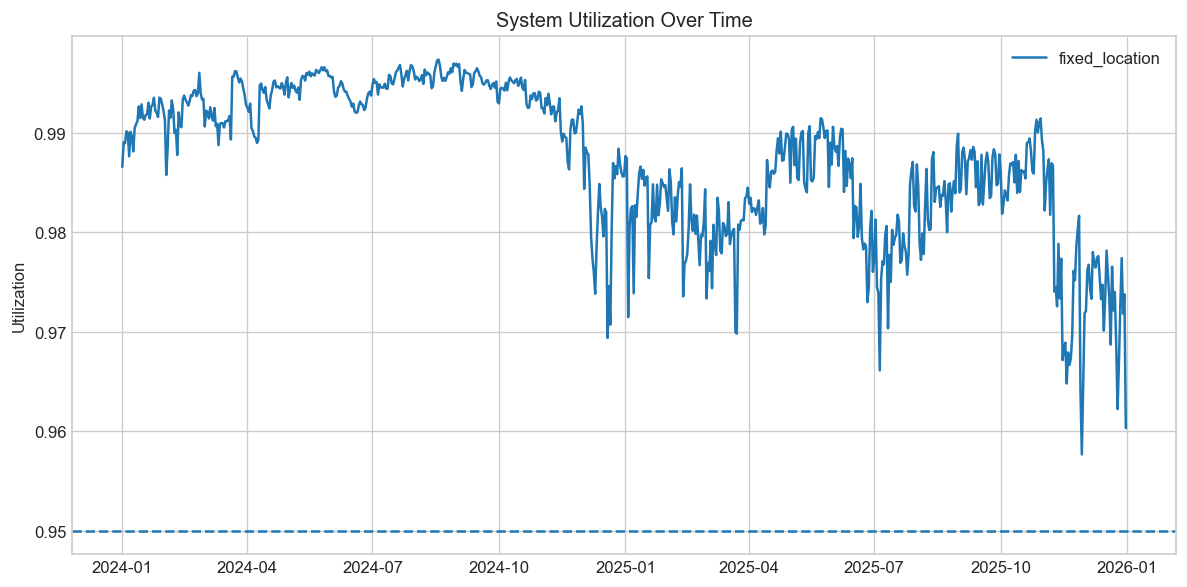

In [9]:
pivot = sysdf.pivot(index="OCCUPANCY_DATE",
                    columns="location_type",
                    values="utilization").sort_index()

plt.figure()
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col)

plt.axhline(0.95, linestyle="--")
plt.title("System Utilization Over Time")
plt.ylabel("Utilization")
plt.legend()
plt.tight_layout()
plt.show()

### System Interpretation

- The shelter system frequently operates near or above the 95% utilization threshold.
- Persistent high utilization reduces buffer capacity.
- Temporary/unassigned capacity plays a role in system stabilization.

In [10]:
top_p95 = (
    loc.groupby("LOCATION_POSTAL_CODE")["p95_utilization_28d"]
       .max()
       .sort_values(ascending=False)
       .head(10)
)

top_p95

LOCATION_POSTAL_CODE
M5V1A3    1.003953
M1B3M6    1.000000
L4L8P5    1.000000
M1E2N8    1.000000
M1E2P4    1.000000
M1E2P9    1.000000
M1E2M6    1.000000
M1G1J6    1.000000
M1H2X1    1.000000
M1H2Z1    1.000000
Name: p95_utilization_28d, dtype: float64

c:\Users\Owner\OneDrive\Desktop\VScode-projects\sdss-public-service\venv\Lib\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname X identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


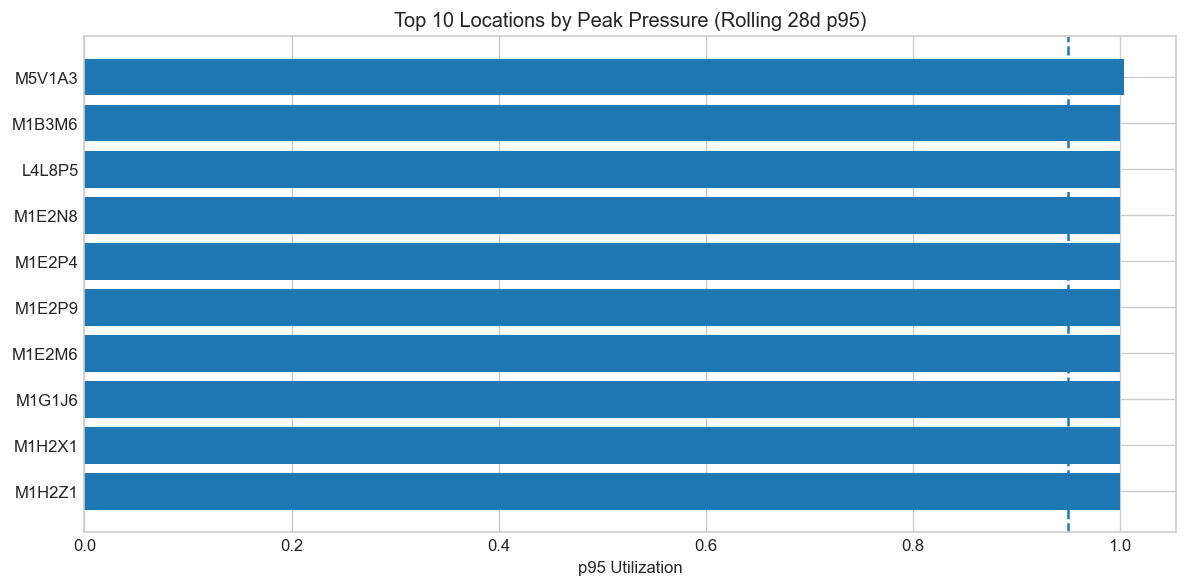

In [11]:
df_bar = top_p95.reset_index()
df_bar.columns = ["Location", "p95_util"]

plt.barh(df_bar["Location"][::-1], df_bar["p95_util"][::-1])
plt.axvline(0.95, linestyle="--")
plt.title("Top 10 Locations by Peak Pressure (Rolling 28d p95)")
plt.xlabel("p95 Utilization")
plt.tight_layout()
plt.show()

In [12]:
top_full = (
    loc.groupby("LOCATION_POSTAL_CODE")["full_rate_7d"]
       .mean()
       .sort_values(ascending=False)
       .head(10)
)

top_full

LOCATION_POSTAL_CODE
M1B3M6    1.0
M1E2M6    1.0
M1E2S2    1.0
M1K2B5    1.0
M1H2Z1    1.0
M4X1L4    1.0
M4T1C1    1.0
M4M2V8    1.0
M4M3C3    1.0
M3N1X1    1.0
Name: full_rate_7d, dtype: float64

In [13]:
top_vol = (
    loc.groupby("LOCATION_POSTAL_CODE")["volatility_28d_std"]
       .max()
       .sort_values(ascending=False)
       .head(10)
)

top_vol

LOCATION_POSTAL_CODE
M5A2K9    0.435179
M5R2T9    0.391185
M5R2T8    0.363899
M2N4N4    0.344417
M1G1J6    0.316158
M4M3G9    0.302008
M6P1X2    0.277088
M6J1W4    0.219116
M5V3C6    0.212640
M5T1N6    0.205950
Name: volatility_28d_std, dtype: float64

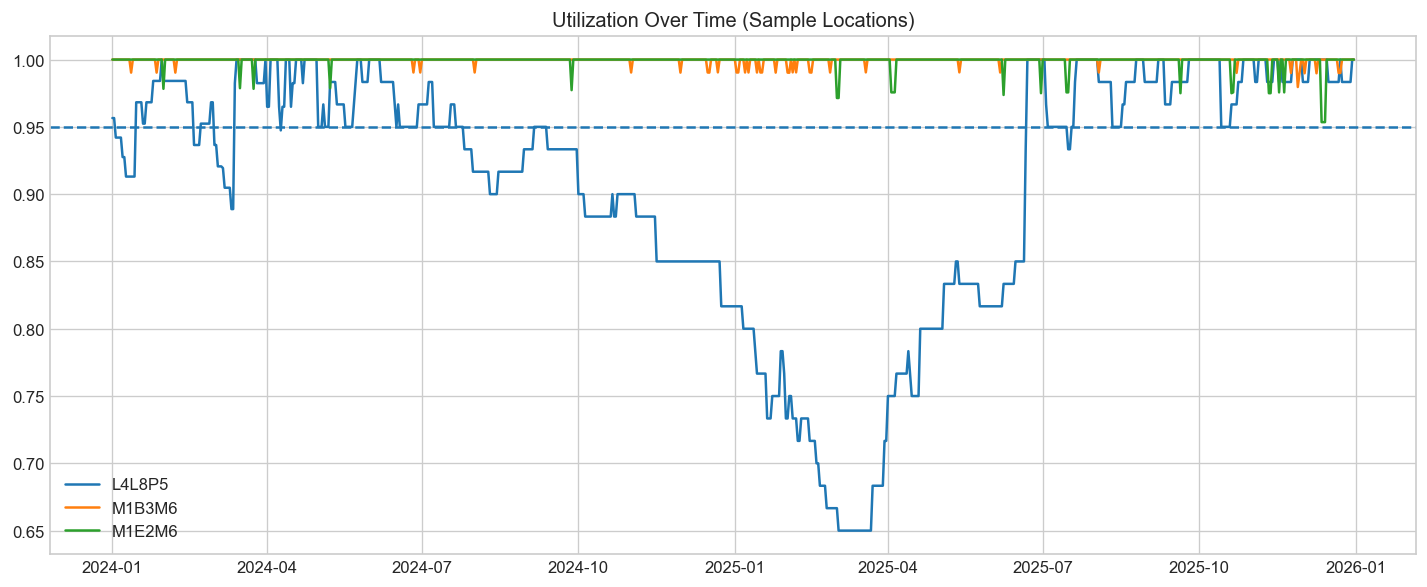

In [14]:
sample_locs = loc["LOCATION_POSTAL_CODE"].dropna().unique()[:3]

plt.figure(figsize=(12, 5))

for l in sample_locs:
    tmp = loc[loc["LOCATION_POSTAL_CODE"] == l].sort_values("OCCUPANCY_DATE")
    plt.plot(tmp["OCCUPANCY_DATE"], tmp["utilization"], label=str(l))

plt.axhline(0.95, linestyle="--")
plt.title("Utilization Over Time (Sample Locations)")
plt.legend()
plt.tight_layout()
plt.show()

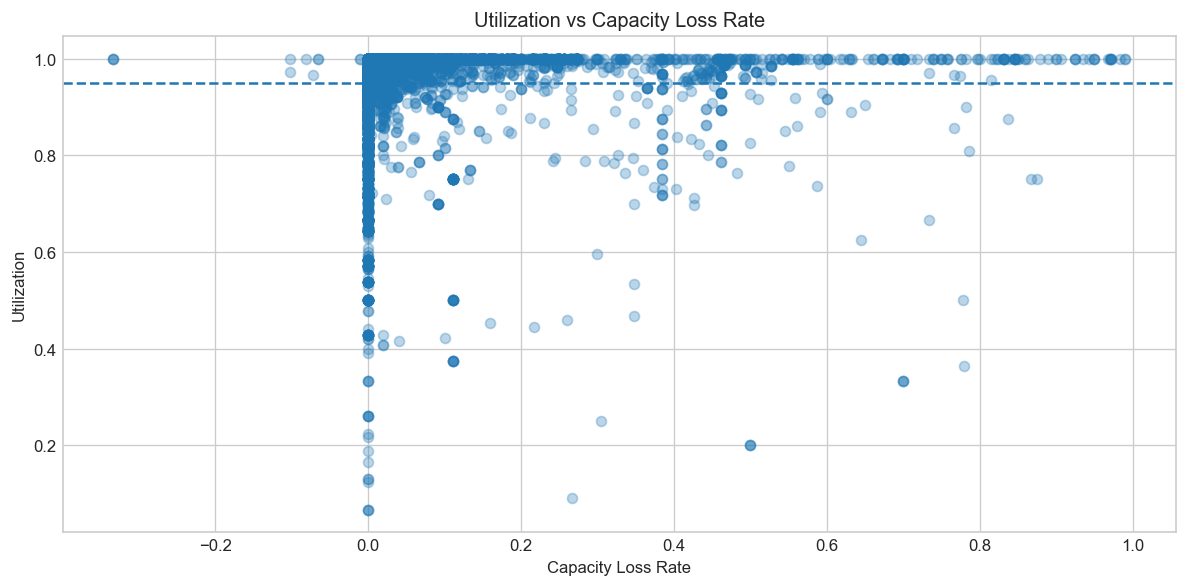

In [15]:
tmp = loc.dropna(subset=["capacity_loss_rate", "utilization"]).copy()

if len(tmp) > 20000:
    tmp = tmp.sample(20000, random_state=42)

plt.scatter(tmp["capacity_loss_rate"], tmp["utilization"], alpha=0.3)
plt.axhline(0.95, linestyle="--")
plt.title("Utilization vs Capacity Loss Rate")
plt.xlabel("Capacity Loss Rate")
plt.ylabel("Utilization")
plt.tight_layout()
plt.show()

In [16]:
run("python src/analysis/quick_qa.py")


▶ Running: python src/analysis/quick_qa.py
Using location column: LOCATION_POSTAL_CODE
Rows: 71026
Unique locations: 111
Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00

Top 10 locations by p95 utilization:
LOCATION_POSTAL_CODE
M5V1A3    1.003953
M1B3M6    1.000000
L4L8P5    1.000000
M1E2N8    1.000000
M1E2P4    1.000000
M1E2P9    1.000000
M1E2M6    1.000000
M1G1J6    1.000000
M1H2X1    1.000000
M1H2Z1    1.000000
Name: p95_utilization_28d, dtype: float64

Top 10 consistently full locations:
LOCATION_POSTAL_CODE
M1B3M6    1.0
M1E2M6    1.0
M1E2S2    1.0
M1K2B5    1.0
M1H2Z1    1.0
M4X1L4    1.0
M4T1C1    1.0
M4M2V8    1.0
M4M3C3    1.0
M3N1X1    1.0
Name: full_rate_7d, dtype: float64
Figure(1000x600)
Figure(1000x600)



## Preliminary Findings

1. The shelter system operates at consistently high utilization levels.
2. Several locations show persistent near-full occupancy.
3. Peak utilization (rolling p95) highlights limited resilience.
4. Capacity loss may exacerbate pressure in high-demand periods.

---

## Next Steps (To Complete Case)

- Sector-level analysis
- Peak vs average resilience comparison
- Scenario simulation (+5% demand)
- Operational recommendations

In [17]:
print(loc.columns.tolist())

['LOCATION_POSTAL_CODE', 'OCCUPANCY_DATE', 'occupied_sum', 'actual_sum', 'unavailable_sum', 'n_rows', 'n_missing_capacity', 'n_over_capacity', 'total_capacity_sum', 'utilization', 'utilization_capped', 'full_flag_95', 'capacity_loss_rate', 'utilization_7d_ma', 'full_rate_7d', 'volatility_28d_std', 'volatility_28d_mad', 'p95_utilization_28d', 'capacity_loss_rate_28d_ma']


In [18]:
# 1) Summarize key metrics by location
loc_summary = (
    loc.groupby("LOCATION_POSTAL_CODE", dropna=True)
       .agg(
           days=("OCCUPANCY_DATE", "count"),
           mean_util=("utilization", "mean"),
           p95_util=("utilization", lambda s: s.quantile(0.95)),
           mean_full_rate_7d=("full_rate_7d", "mean"),
           max_volatility_28d=("volatility_28d_std", "max"),
           mean_capacity_loss=("capacity_loss_rate", "mean"),
       )
       .reset_index()
)

loc_summary.sort_values("mean_util", ascending=False).head(10)

,LOCATION_POSTAL_CODE,days,mean_util,p95_util,mean_full_rate_7d,max_volatility_28d,mean_capacity_loss
38,M4X1L4,731,1.000000,1.0,1.0,0.000000,0.013371
75,M5T2M8,731,1.000000,1.0,1.0,0.000000,0.000000
73,M5T1J5,731,1.000000,1.0,1.0,0.000000,0.000000
94,M6J1A8,164,1.000000,1.0,1.0,0.000000,0.137927
109,M9W6P8,731,0.999991,1.0,1.0,0.001252,0.073495
103,M8Y1A3,731,0.999967,1.0,1.0,0.004609,0.027017
61,M5C2H4,731,0.999965,1.0,1.0,0.002423,0.001508
16,M1T3G2,661,0.999950,1.0,1.0,0.001562,0.210653
101,M6R2K3,731,0.999930,1.0,1.0,0.004846,0.027293
28,M3N1X1,731,0.999924,1.0,1.0,0.002908,0.082880


In [19]:
# 2) Resilience gap: difference between typical and peak pressure
loc_summary["resilience_gap"] = loc_summary["p95_util"] - loc_summary["mean_util"]

loc_summary.sort_values("resilience_gap", ascending=False).head(10)

,LOCATION_POSTAL_CODE,days,mean_util,p95_util,mean_full_rate_7d,max_volatility_28d,mean_capacity_loss,resilience_gap
66,M5R2T1,731,0.753775,1.000000,0.077014,0.148600,0.000091,0.246225
95,M6J1W4,118,0.641949,0.875000,0.017241,0.219116,0.118644,0.233051
34,M4M3G9,23,0.799821,1.000000,0.599773,0.302008,0.044928,0.200179
72,M5S2P9,731,0.739398,0.916667,0.004115,0.127294,0.000000,0.177269
67,M5R2T8,250,0.846244,1.000000,0.592368,0.363899,0.049953,0.153756
45,M5A2K9,240,0.861932,1.000000,0.626050,0.435179,0.032083,0.138068
74,M5T1N6,28,0.868357,1.000000,0.566941,0.205950,0.242857,0.131643
44,M5A2E5,206,0.657751,0.780000,0.000000,0.111517,0.026893,0.122249
23,M2N4N4,221,0.886150,1.000000,0.680061,0.344417,0.120245,0.113850
26,M3M2X4,706,0.902178,1.000000,0.280641,0.112229,0.017450,0.097822


In [20]:
def minmax(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

# 3) Normalize metrics to 0-1 scale for composite index
loc_summary["mean_util_n"] = minmax(loc_summary["mean_util"])
loc_summary["p95_util_n"] = minmax(loc_summary["p95_util"])
loc_summary["volatility_n"] = minmax(loc_summary["max_volatility_28d"])
loc_summary["caploss_n"] = minmax(loc_summary["mean_capacity_loss"])

# 4) Pressure Index
w_mean, w_p95, w_vol, w_loss = 0.4, 0.3, 0.2, 0.1
loc_summary["pressure_index"] = (
    w_mean * loc_summary["mean_util_n"]
  + w_p95  * loc_summary["p95_util_n"]
  + w_vol  * loc_summary["volatility_n"]
  + w_loss * loc_summary["caploss_n"]
)

loc_summary.sort_values("pressure_index", ascending=False).head(10)

,LOCATION_POSTAL_CODE,days,mean_util,p95_util,mean_full_rate_7d,max_volatility_28d,mean_capacity_loss,resilience_gap,mean_util_n,p95_util_n,volatility_n,caploss_n,pressure_index
68,M5R2T9,690,0.979300,1.0,0.908430,0.391185,0.000483,0.020700,0.955916,1.0,0.898906,0.003067,0.862454
7,M1G1J6,291,0.921982,1.0,0.692025,0.316158,0.172952,0.078018,0.833853,1.0,0.726500,0.497776,0.828619
57,M5B2G8,199,0.992609,1.0,1.000000,0.014912,0.348042,0.007391,0.984259,1.0,0.034266,1.000000,0.800557
99,M6P1X2,440,0.963070,1.0,0.742009,0.277088,0.013636,0.036930,0.921354,1.0,0.636722,0.040796,0.799966
23,M2N4N4,221,0.886150,1.0,0.680061,0.344417,0.120245,0.113850,0.757543,1.0,0.791436,0.346590,0.795963
45,M5A2K9,240,0.861932,1.0,0.626050,0.435179,0.032083,0.138068,0.705968,1.0,1.000000,0.093709,0.791758
81,M5V3C6,111,0.953030,1.0,0.803189,0.212640,0.091116,0.046970,0.899972,1.0,0.488627,0.263038,0.784018
4,M1E2P4,682,0.996524,1.0,0.994118,0.176669,0.012252,0.003476,0.992598,1.0,0.405969,0.036824,0.781915
62,M5G1P4,275,0.939994,1.0,0.716658,0.197744,0.140933,0.060006,0.872211,1.0,0.454397,0.405931,0.780357
102,M8V3H9,391,0.978274,1.0,0.861421,0.139820,0.100863,0.021726,0.953733,1.0,0.321293,0.290996,0.774851


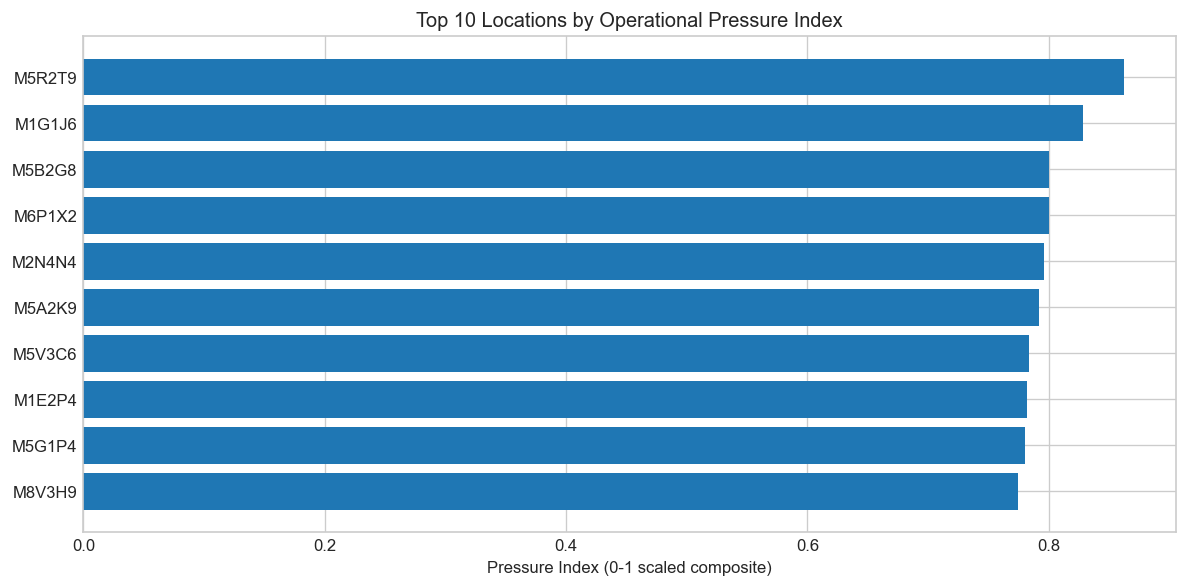

In [21]:
top10 = loc_summary.sort_values("pressure_index", ascending=False).head(10).copy()
top10 = top10.sort_values("pressure_index")

plt.figure(figsize=(10, 5))
plt.barh(top10["LOCATION_POSTAL_CODE"], top10["pressure_index"])
plt.title("Top 10 Locations by Operational Pressure Index")
plt.xlabel("Pressure Index (0-1 scaled composite)")
plt.tight_layout()
plt.show()

In [22]:
scenario = loc[["OCCUPANCY_DATE","LOCATION_POSTAL_CODE","occupied_sum","actual_sum"]].dropna().copy()

# base utilization
scenario["util_base"] = scenario["occupied_sum"] / scenario["actual_sum"].replace(0, np.nan)

# scenario: demand +5%
scenario["occupied_plus5"] = scenario["occupied_sum"] * 1.05
scenario["util_plus5"] = scenario["occupied_plus5"] / scenario["actual_sum"].replace(0, np.nan)

# Near-full（95%） Over-capacity（>100%）
scenario["near_full_base"] = scenario["util_base"] >= 0.95
scenario["near_full_plus5"] = scenario["util_plus5"] >= 0.95
scenario["overcap_base"] = scenario["util_base"] > 1.0
scenario["overcap_plus5"] = scenario["util_plus5"] > 1.0

scenario.head()

,OCCUPANCY_DATE,LOCATION_POSTAL_CODE,occupied_sum,actual_sum,util_base,occupied_plus5,util_plus5,near_full_base,near_full_plus5,overcap_base,overcap_plus5
0,2024-01-01,L4L8P5,66,69,0.956522,69.30,1.004348,True,True,False,True
1,2024-01-02,L4L8P5,66,69,0.956522,69.30,1.004348,True,True,False,True
2,2024-01-03,L4L8P5,65,69,0.942029,68.25,0.989130,False,True,False,False
3,2024-01-04,L4L8P5,65,69,0.942029,68.25,0.989130,False,True,False,False
4,2024-01-05,L4L8P5,65,69,0.942029,68.25,0.989130,False,True,False,False


In [23]:
impact = pd.DataFrame({
    "avg_util": [
        scenario["util_base"].mean(),
        scenario["util_plus5"].mean()
    ],
    "pct_days_near_full": [
        scenario["near_full_base"].mean(),
        scenario["near_full_plus5"].mean()
    ],
    "pct_days_over_capacity": [
        scenario["overcap_base"].mean(),
        scenario["overcap_plus5"].mean()
    ],
}, index=["Baseline", "Demand +5%"])

impact

,avg_util,pct_days_near_full,pct_days_over_capacity
Baseline,0.978182,0.888140,0.000056
Demand +5%,1.027091,0.933714,0.883648


In [24]:
loc_impact = (
    scenario.groupby("LOCATION_POSTAL_CODE")
            .agg(
                pct_near_full_base=("near_full_base","mean"),
                pct_near_full_plus5=("near_full_plus5","mean"),
                pct_overcap_base=("overcap_base","mean"),
                pct_overcap_plus5=("overcap_plus5","mean"),
            )
            .reset_index()
)

loc_impact["delta_near_full"] = loc_impact["pct_near_full_plus5"] - loc_impact["pct_near_full_base"]
loc_impact["delta_overcap"] = loc_impact["pct_overcap_plus5"] - loc_impact["pct_overcap_base"]

loc_impact.sort_values("delta_overcap", ascending=False).head(10)

,LOCATION_POSTAL_CODE,pct_near_full_base,pct_near_full_plus5,pct_overcap_base,pct_overcap_plus5,delta_near_full,delta_overcap
1,M1B3M6,1.0,1.0,0.0,1.0,0.0,1.0
2,M1E2M6,1.0,1.0,0.0,1.0,0.0,1.0
6,M1E2S2,1.0,1.0,0.0,1.0,0.0,1.0
9,M1H2Z1,1.0,1.0,0.0,1.0,0.0,1.0
18,M2J4R1,1.0,1.0,0.0,1.0,0.0,1.0
17,M2H3H9,1.0,1.0,0.0,1.0,0.0,1.0
38,M4X1L4,1.0,1.0,0.0,1.0,0.0,1.0
32,M4M2V8,1.0,1.0,0.0,1.0,0.0,1.0
33,M4M3C3,1.0,1.0,0.0,1.0,0.0,1.0
28,M3N1X1,1.0,1.0,0.0,1.0,0.0,1.0


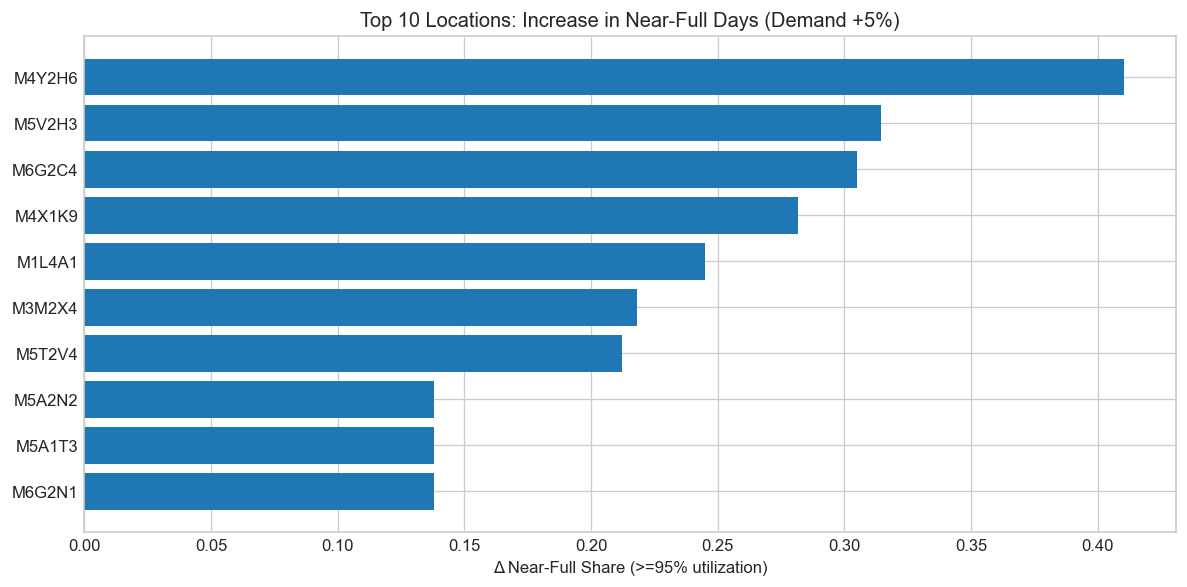

In [25]:
top_delta = loc_impact.sort_values("delta_near_full", ascending=False).head(10).sort_values("delta_near_full")

plt.figure(figsize=(10, 5))
plt.barh(top_delta["LOCATION_POSTAL_CODE"], top_delta["delta_near_full"])
plt.title("Top 10 Locations: Increase in Near-Full Days (Demand +5%)")
plt.xlabel("Δ Near-Full Share (>=95% utilization)")
plt.tight_layout()
plt.show()

In [26]:
# define thresholds (operational thresholds)
high_mean_threshold = 0.95
high_gap_threshold = loc_summary["resilience_gap"].quantile(0.75)

loc_summary["risk_type"] = "Stable"

loc_summary.loc[
    loc_summary["mean_util"] >= high_mean_threshold,
    "risk_type"
] = "Chronic High Pressure"

loc_summary.loc[
    (loc_summary["resilience_gap"] >= high_gap_threshold)
    & (loc_summary["mean_util"] < high_mean_threshold),
    "risk_type"
] = "Peak Fragile"

loc_summary["risk_type"].value_counts()

risk_type
Chronic High Pressure    91
Peak Fragile             19
Stable                    1
Name: count, dtype: int64

In [27]:
loc_summary.sort_values("pressure_index", ascending=False).head(15)[
    ["LOCATION_POSTAL_CODE", "mean_util", "p95_util", "resilience_gap", "pressure_index", "risk_type"]
]

,LOCATION_POSTAL_CODE,mean_util,p95_util,resilience_gap,pressure_index,risk_type
68,M5R2T9,0.979300,1.0,0.020700,0.862454,Chronic High Pressure
7,M1G1J6,0.921982,1.0,0.078018,0.828619,Peak Fragile
57,M5B2G8,0.992609,1.0,0.007391,0.800557,Chronic High Pressure
99,M6P1X2,0.963070,1.0,0.036930,0.799966,Chronic High Pressure
23,M2N4N4,0.886150,1.0,0.113850,0.795963,Peak Fragile
45,M5A2K9,0.861932,1.0,0.138068,0.791758,Peak Fragile
81,M5V3C6,0.953030,1.0,0.046970,0.784018,Chronic High Pressure
4,M1E2P4,0.996524,1.0,0.003476,0.781915,Chronic High Pressure
62,M5G1P4,0.939994,1.0,0.060006,0.780357,Peak Fragile
102,M8V3H9,0.978274,1.0,0.021726,0.774851,Chronic High Pressure


In [28]:
impact["delta_near_full"] = impact["pct_days_near_full"].diff()
impact["delta_overcap"] = impact["pct_days_over_capacity"].diff()

impact

,avg_util,pct_days_near_full,pct_days_over_capacity,delta_near_full,delta_overcap
Baseline,0.978182,0.888140,0.000056,NaN,NaN
Demand +5%,1.027091,0.933714,0.883648,0.045575,0.883592


In [29]:
danger_zones = loc_impact.sort_values("delta_overcap", ascending=False).head(10)

danger_zones[[
    "LOCATION_POSTAL_CODE",
    "pct_overcap_base",
    "pct_overcap_plus5",
    "delta_overcap"
]]

,LOCATION_POSTAL_CODE,pct_overcap_base,pct_overcap_plus5,delta_overcap
1,M1B3M6,0.0,1.0,1.0
2,M1E2M6,0.0,1.0,1.0
6,M1E2S2,0.0,1.0,1.0
9,M1H2Z1,0.0,1.0,1.0
18,M2J4R1,0.0,1.0,1.0
17,M2H3H9,0.0,1.0,1.0
38,M4X1L4,0.0,1.0,1.0
32,M4M2V8,0.0,1.0,1.0
33,M4M3C3,0.0,1.0,1.0
28,M3N1X1,0.0,1.0,1.0


In [30]:
final_table = loc_summary.merge(
    loc_impact[[
        "LOCATION_POSTAL_CODE",
        "delta_near_full",
        "delta_overcap"
    ]],
    on="LOCATION_POSTAL_CODE",
    how="left"
)

final_table = final_table.sort_values("pressure_index", ascending=False)

final_table.head(10)

,LOCATION_POSTAL_CODE,days,mean_util,p95_util,mean_full_rate_7d,max_volatility_28d,mean_capacity_loss,resilience_gap,mean_util_n,p95_util_n,volatility_n,caploss_n,pressure_index,risk_type,delta_near_full,delta_overcap
68,M5R2T9,690,0.979300,1.0,0.908430,0.391185,0.000483,0.020700,0.955916,1.0,0.898906,0.003067,0.862454,Chronic High Pressure,0.050725,0.904348
7,M1G1J6,291,0.921982,1.0,0.692025,0.316158,0.172952,0.078018,0.833853,1.0,0.726500,0.497776,0.828619,Peak Fragile,0.058419,0.690722
57,M5B2G8,199,0.992609,1.0,1.000000,0.014912,0.348042,0.007391,0.984259,1.0,0.034266,1.000000,0.800557,Chronic High Pressure,0.000000,1.000000
99,M6P1X2,440,0.963070,1.0,0.742009,0.277088,0.013636,0.036930,0.921354,1.0,0.636722,0.040796,0.799966,Chronic High Pressure,0.031818,0.745455
23,M2N4N4,221,0.886150,1.0,0.680061,0.344417,0.120245,0.113850,0.757543,1.0,0.791436,0.346590,0.795963,Peak Fragile,0.067873,0.674208
45,M5A2K9,240,0.861932,1.0,0.626050,0.435179,0.032083,0.138068,0.705968,1.0,1.000000,0.093709,0.791758,Peak Fragile,0.070833,0.620833
81,M5V3C6,111,0.953030,1.0,0.803189,0.212640,0.091116,0.046970,0.899972,1.0,0.488627,0.263038,0.784018,Chronic High Pressure,0.081081,0.774775
4,M1E2P4,682,0.996524,1.0,0.994118,0.176669,0.012252,0.003476,0.992598,1.0,0.405969,0.036824,0.781915,Chronic High Pressure,0.004399,0.994135
62,M5G1P4,275,0.939994,1.0,0.716658,0.197744,0.140933,0.060006,0.872211,1.0,0.454397,0.405931,0.780357,Peak Fragile,0.094545,0.701818
102,M8V3H9,391,0.978274,1.0,0.861421,0.139820,0.100863,0.021726,0.953733,1.0,0.321293,0.290996,0.774851,Chronic High Pressure,0.092072,0.838875


## Key Insights

### 1. Chronic Structural Strain
Several locations operate persistently above 95% utilization,
indicating structural capacity shortages rather than temporary fluctuations.

### 2. Peak Fragility
Some locations exhibit moderate average utilization but extreme peak pressure,
suggesting insufficient buffering capacity during demand surges.

### 3. System Sensitivity to Demand Growth
A modest +5% demand increase significantly raises:
- The share of near-full days
- The share of over-capacity days

This suggests the system operates close to critical thresholds.

### 4. Capacity Loss as a Multiplier
Even modest capacity loss compounds pressure in already strained locations.